<a href="https://colab.research.google.com/github/SOURAV143-BIT/PROJECTSS/blob/main/HOSPITAL_CARE_ANALYSIS_PROJECT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **HOSPITAL CARE ANALYSIS PROJECT**

IMPORTING LIBRARIES THAT I NEED

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

loading dataset

In [ ]:
df=pd.read_csv("/content/hospital_dataset.csv")


viewing some data

In [ ]:
df.head()

,Patient_ID,Age,Gender,Disease,Department,Admission_Date,Discharge_Date,Stay_Days,Bill_Amount,Payment_Type,Readmitted
0,1,40,Female,Diabetes,Endocrinology,2024-11-29,2024-12-05,6,6427,Cash,No
1,2,31,Female,Hypertension,Cardiology,2024-08-10,2024-08-17,7,2333,Insurance,No
2,3,80,Male,Infection,General Medicine,2024-08-22,2024-08-30,8,47765,Insurance,Yes
3,4,61,Male,Hypertension,Cardiology,2024-07-20,2024-07-22,2,28106,Cash,No
4,5,26,Male,Infection,General Medicine,2024-03-20,2024-03-29,9,34757,Insurance,No


lets try to understand our data more

In [ ]:
df.describe()

,Patient_ID,Age,Stay_Days,Bill_Amount
count,500.000000,500.000000,500.000000,500.000000
mean,250.500000,48.892000,5.402000,26403.366000
std,144.481833,18.313249,2.904698,13803.836502
min,1.000000,18.000000,1.000000,2108.000000
25%,125.750000,33.000000,3.000000,15081.000000
50%,250.500000,48.000000,5.000000,26403.500000
75%,375.250000,65.000000,8.000000,38512.000000
max,500.000000,80.000000,10.000000,49914.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Patient_ID      500 non-null    int64 
 1   Age             500 non-null    int64 
 2   Gender          500 non-null    object
 3   Disease         500 non-null    object
 4   Department      500 non-null    object
 5   Admission_Date  500 non-null    object
 6   Discharge_Date  500 non-null    object
 7   Stay_Days       500 non-null    int64 
 8   Bill_Amount     500 non-null    int64 
 9   Payment_Type    500 non-null    object
 10  Readmitted      500 non-null    object
dtypes: int64(4), object(7)
memory usage: 43.1+ KB


## lets do eda (exploritaory data analysis)

In [ ]:
df.isnull().sum()

,0
Patient_ID,0
Age,0
Gender,0
Disease,0
Department,0
Admission_Date,0
Discharge_Date,0
Stay_Days,0
Bill_Amount,0
Payment_Type,0


In [ ]:
df.duplicated().sum()

np.int64(0)

THERE ARE NO NULL AND NO DUPLICATE VALUES

lets analyse our data

lets see in which department patients are more

In [ ]:
# Count patients by department
dept_counts = df['Department'].value_counts()
print(dept_counts)


Department
Cardiology          170
Endocrinology        88
Pulmonology          87
Orthopedic           78
General Medicine     77
Name: count, dtype: int64


In [ ]:
# Average stay duration per disease
avg_stay = df.groupby('Disease')['Stay_Days'].mean()
print(avg_stay)



Disease
Asthma           5.344828
Diabetes         5.306818
Fracture         5.871795
Heart Disease    5.439024
Hypertension     5.431818
Infection        5.025974
Name: Stay_Days, dtype: float64


In [ ]:
# Average bill amount per department
avg_bill = df.groupby('Department')['Bill_Amount'].mean()
print(avg_bill)


Department
Cardiology          26484.288235
Endocrinology       27138.943182
General Medicine    27397.532468
Orthopedic          24136.948718
Pulmonology         26653.275862
Name: Bill_Amount, dtype: float64


In [ ]:

# Readmission rate
readmit_rate = df['Readmitted'].value_counts(normalize=True) * 100
print(readmit_rate)


Readmitted
No     91.6
Yes     8.4
Name: proportion, dtype: float64


lets visualise our data

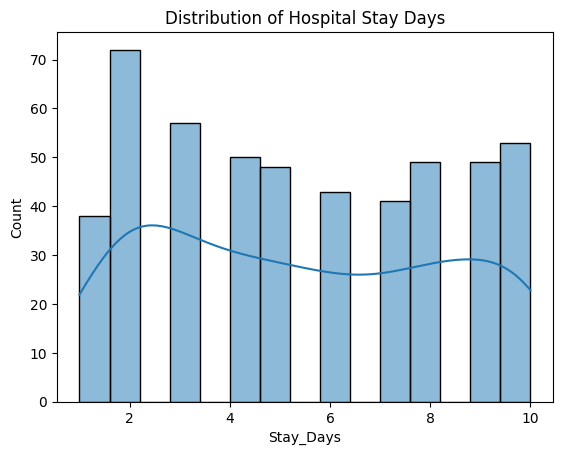

In [ ]:

# Distribution of Stay_Days
sns.histplot(df['Stay_Days'], bins=15, kde=True)
plt.title("Distribution of Hospital Stay Days")
plt.show()



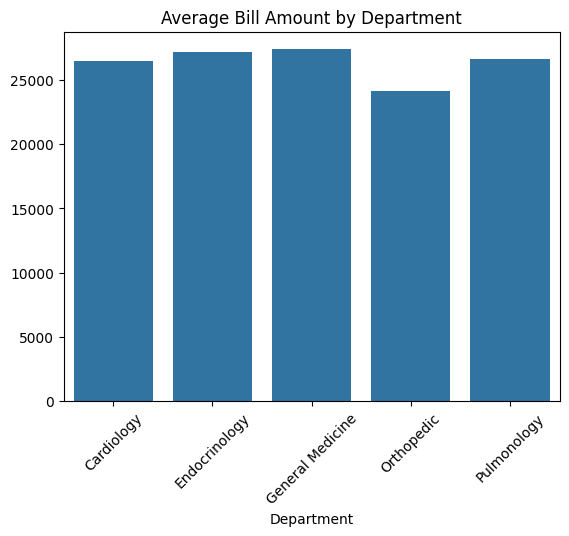

In [ ]:

# Average bill per department
sns.barplot(x=avg_bill.index, y=avg_bill.values)
plt.title("Average Bill Amount by Department")
plt.xticks(rotation=45)
plt.show()


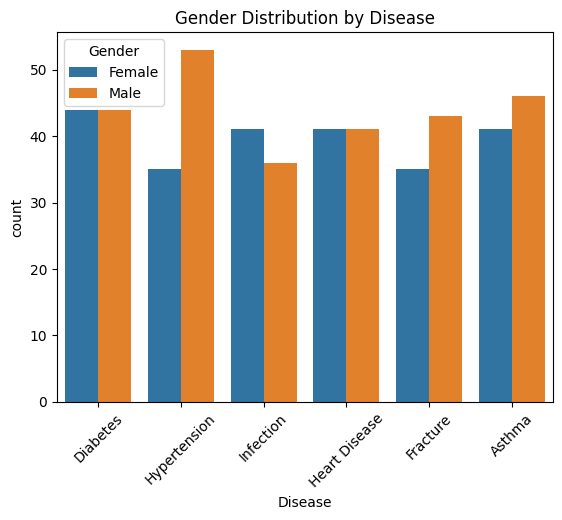

In [ ]:

# Gender distribution per disease
sns.countplot(data=df, x="Disease", hue="Gender")
plt.title("Gender Distribution by Disease")
plt.xticks(rotation=45)
plt.show()

Readmitted            No        Yes
Disease                            
Asthma         95.402299   4.597701
Diabetes       92.045455   7.954545
Fracture       93.589744   6.410256
Heart Disease  87.804878  12.195122
Hypertension   90.909091   9.090909
Infection      89.610390  10.389610


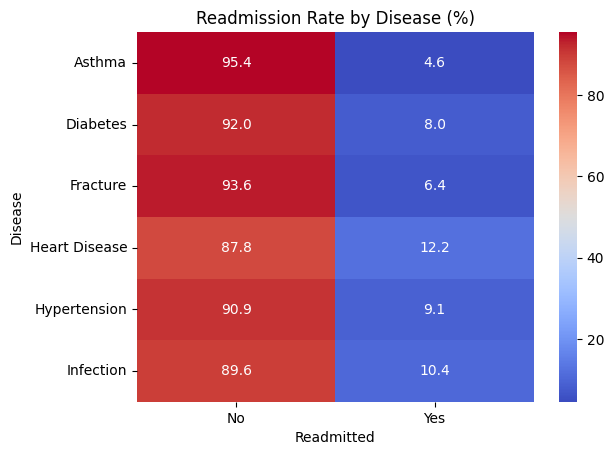

In [ ]:
# Readmission by disease
readmit_disease = df.groupby('Disease')['Readmitted'].value_counts(normalize=True).unstack() * 100
print(readmit_disease)

sns.heatmap(readmit_disease, annot=True, cmap="coolwarm", fmt=".1f")
plt.title("Readmission Rate by Disease (%)")
plt.show()


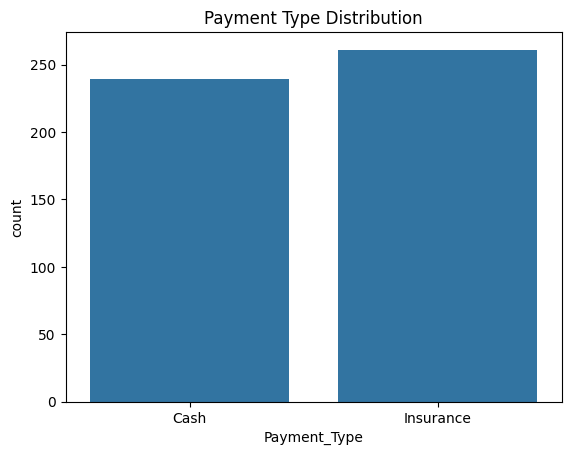

In [ ]:
# Payment type distribution
sns.countplot(data=df, x="Payment_Type")
plt.title("Payment Type Distribution")
plt.show()



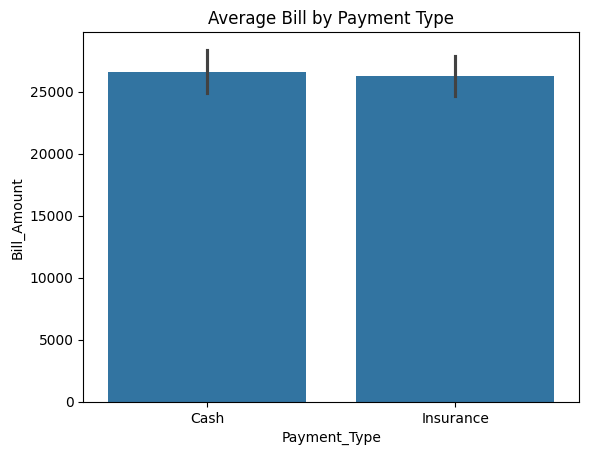

In [ ]:
# Average bill by payment type
sns.barplot(data=df, x="Payment_Type", y="Bill_Amount")
plt.title("Average Bill by Payment Type")
plt.show()


             Stay_Days  Bill_Amount
Stay_Days     1.000000     0.024759
Bill_Amount   0.024759     1.000000


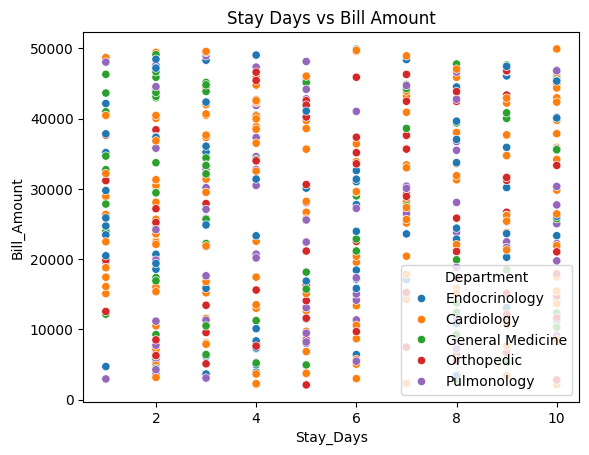

In [ ]:
# Correlation between stay days and bill amount
corr = df[['Stay_Days','Bill_Amount']].corr()
print(corr)

sns.scatterplot(data=df, x="Stay_Days", y="Bill_Amount", hue="Department")
plt.title("Stay Days vs Bill Amount")
plt.show()



Age_Group
0-20      26172.695652
21-40     27200.564417
41-60     24808.651316
61-80     27130.271605
81-100             NaN
Name: Bill_Amount, dtype: float64


/tmp/ipykernel_4435/451495864.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_bill = df.groupby('Age_Group')['Bill_Amount'].mean()


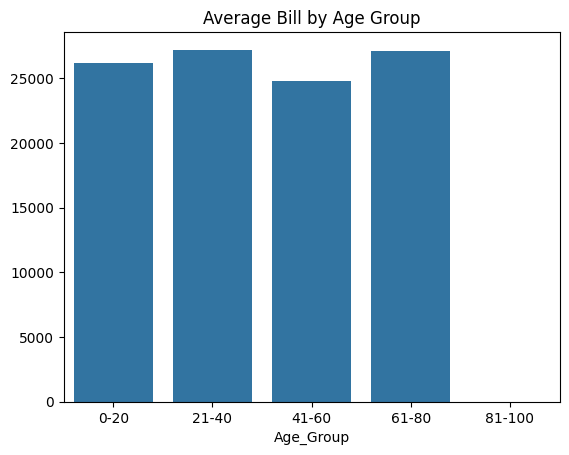

In [ ]:

# Age group analysis
df['Age_Group'] = pd.cut(df['Age'], bins=[0,20,40,60,80,100], labels=['0-20','21-40','41-60','61-80','81-100'])
age_bill = df.groupby('Age_Group')['Bill_Amount'].mean()
print(age_bill)

sns.barplot(x=age_bill.index, y=age_bill.values)
plt.title("Average Bill by Age Group")
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Encoding categorical variables
categorical_cols = ['Gender','Disease','Department','Payment_Type','Readmitted']
le_dict = {}
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    le_dict[col] = le  # store encoders if needed later

# Features and target (predicting Readmission)
# Drop 'Age_Group' as it's a categorical string column not suitable for direct numerical input,
# and 'Age' already provides similar numerical information.
X = df.drop(['Patient_ID','Admission_Date','Discharge_Date','Readmitted', 'Age_Group'], axis=1)
y = df['Readmitted']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Train Random Forest
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

# Predictions
y_pred = clf.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.91
Confusion Matrix:
 [[90  2]
 [ 7  1]]
Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.98      0.95        92
           1       0.33      0.12      0.18         8

    accuracy                           0.91       100
   macro avg       0.63      0.55      0.57       100
weighted avg       0.88      0.91      0.89       100



In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Target: Bill_Amount

X_reg= df.drop(['Patient_ID','Admission_Date','Discharge_Date','Readmitted', 'Age_Group'], axis=1)
y_reg = df['Bill_Amount']

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

# Train Random Forest Regressor
reg = RandomForestRegressor(n_estimators=100, random_state=42)
reg.fit(X_train_r, y_train_r)

# Predictions
y_pred_r = reg.predict(X_test_r)

# Evaluation
print("RMSE:", np.sqrt(mean_squared_error(y_test_r, y_pred_r)))
print("R² Score:", r2_score(y_test_r, y_pred_r))


RMSE: 93.52797001432252
R² Score: 0.9999544585749646


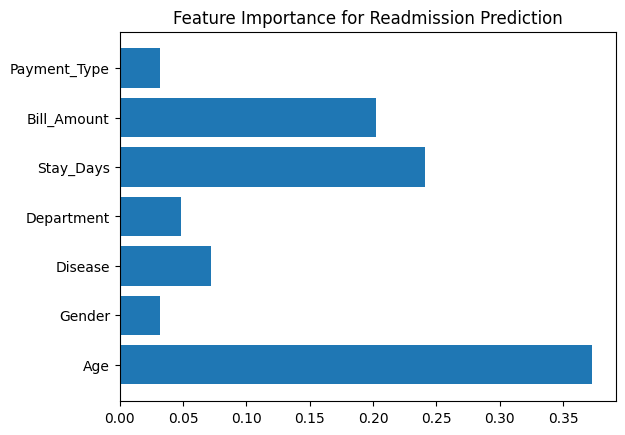

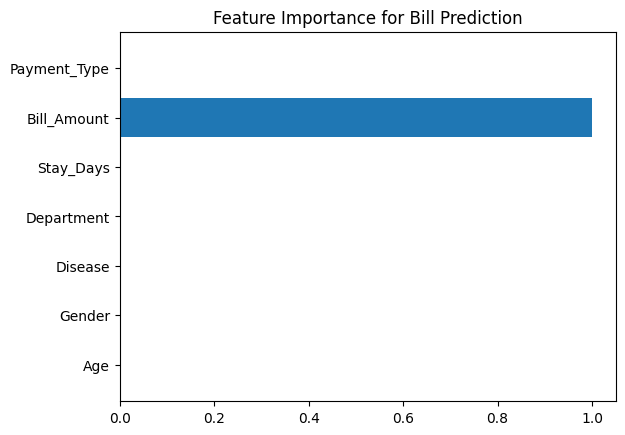

In [ ]:
import matplotlib.pyplot as plt

# For classification
importances = clf.feature_importances_
features = X.columns
plt.barh(features, importances)
plt.title("Feature Importance for Readmission Prediction")
plt.show()

# For regression
importances_r = reg.feature_importances_
plt.barh(features, importances_r)
plt.title("Feature Importance for Bill Prediction")
plt.show()
